In [1]:
# Общие настройки
import os, math, random, re, json, time
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (5,3)

import torch
import torch.nn as nn
import torch.nn.functional as F

from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer as SkTFIDF


RNG_SEED = 42
def set_seed(seed=RNG_SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
set_seed()

# viz helpers
def plot_curve(values, title, ylabel="score", xlabel="step"):
    xs = np.arange(1, len(values)+1)
    plt.plot(xs, values, marker="o")
    plt.title(title); plt.xlabel(xlabel); plt.ylabel(ylabel); plt.grid(True)
    plt.show()

def plot_confusion(cm, labels):
    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]),
           xticklabels=labels, yticklabels=labels, ylabel='True', xlabel='Pred')
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout(); plt.show()

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

## Attention своими руками + позиционные эмбеддинги

**Задача:** реализовать attention/MHA/positional

**Данные:** Мини-корпус tiny Shakespeare

**Решение:** attention, causal mask, RoPE vs sinusoidal

**Результаты:** perplexity/loss + примеры генерации (3–5 строк)

**Bonus:** влияние pos enc

In [2]:
# ======= DATA: simple char dataset =======
def tiny_char_data():
    text = (
        "To be, or not to be, that is the question:\n"
        "Whether 'tis nobler in the mind to suffer\n"
        "The slings and arrows of outrageous fortune,\n"
        "Or to take arms against a sea of troubles,\n"
    ) * 100
    vocab = sorted(set(text))
    stoi = {ch:i for i,ch in enumerate(vocab)}
    itos = {i:ch for ch,i in stoi.items()}
    ids = torch.tensor([stoi[ch] for ch in text], dtype=torch.long)
    split = int(0.9*len(ids))
    return ids[:split], ids[split:], stoi, itos

def causal_mask(T, device):
    # True = разрешено, False = запрещено (будущее)
    return torch.tril(torch.ones(T, T, device=device, dtype=torch.bool)).view(1,1,T,T)

def show_attention_heatmap(attn, x_ticks=None, y_ticks=None, title="Attention"):
    if isinstance(attn, torch.Tensor):
        attn = attn.detach().cpu().numpy()
    if attn.ndim == 4:      # [B,h,T,T] -> среднее
        attn = attn.mean(axis=(0,1))
    elif attn.ndim == 3:    # [h,T,T] или [B,T,T]
        attn = attn.mean(axis=0)
    elif attn.ndim != 2:
        raise ValueError(f"Unexpected attn shape {attn.shape}")
    plt.imshow(attn, aspect='auto', cmap='magma')
    if x_ticks is not None: plt.xticks(range(len(x_ticks)), x_ticks, rotation=90)
    if y_ticks is not None: plt.yticks(range(len(y_ticks)), y_ticks)
    plt.title(title); plt.colorbar(); plt.tight_layout(); plt.show()

def plot_curve(values, title, ylabel="loss", xlabel="step/epoch"):
    xs = np.arange(1, len(values)+1)
    plt.plot(xs, values, marker="o"); plt.grid(True)
    plt.title(title); plt.xlabel(xlabel); plt.ylabel(ylabel); plt.show()


In [3]:
# ===== RoPE helpers =====
def rope_cache(T, d, device, base=10000):
    """
    Возвращает cos, sin формы [1,1,T,d/2] для данного d.
    """
    pos = torch.arange(T, device=device).unsqueeze(-1)     # [T,1]
    idx = torch.arange(0, d, 2, device=device).float()     # [d/2]
    freqs = 1.0 / (base ** (idx / d))                      # [d/2]
    theta = pos * freqs                                    # [T,d/2]
    cos, sin = torch.cos(theta)[None,None], torch.sin(theta)[None,None]  # [1,1,T,d/2]
    return cos, sin

def rope_rotate(x, cos, sin):
    """
    x: [B,h,T,d] (d чётное), cos/sin: [1,1,T,d/2]
    Возвращает x, повёрнутый по парам (even, odd).
    """
    even = x[..., 0::2]
    odd = x[..., 1::2]
    rot_even = even * cos - odd * sin
    rot_odd = even * sin + odd * cos

    out = torch.empty_like(x)
    out[..., 0::2] = rot_even
    out[..., 1::2] = rot_odd
    return out


In [4]:
# ===== Attention blocks =====
class ScaledDotProductAttention(nn.Module):
    def __init__(self, dropout=0.0):
        super().__init__()
        self.drop = nn.Dropout(dropout)
    def forward(self, Q, K, V, attn_mask=None):
        """
        Q,K,V: [B,h,T,d]
        Возвращает: out [B,h,T,d], attn_probs [B,h,T,T]
        """
        scores = (Q @ K.transpose(-2, -1)) / (Q.shape[-1]**.5)
        if attn_mask is not None:
            scores = scores.masked_fill(attn_mask == 0, float('-inf'))
        p = torch.softmax(scores, dim=-1)
        p = self.drop(p)
        out = p @ V
        return out, p

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.0, pos_mode="sine"):
        super().__init__()
        assert d_model % n_heads == 0
        self.h = n_heads
        self.dh = d_model // n_heads
        self.pos_mode = pos_mode
        self.Wq = nn.Linear(d_model, d_model, bias=False)
        self.Wk = nn.Linear(d_model, d_model, bias=False)
        self.Wv = nn.Linear(d_model, d_model, bias=False)
        self.Wo = nn.Linear(d_model, d_model, bias=False)
        self.sdpa = ScaledDotProductAttention(dropout)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, attn_mask=None, sine_pe=None, rope=None):
        """
        x: [B,T,C], sine_pe: [1,MaxT,C] (если pos_mode='sine')
        rope: (cos,sin) для d_head (если pos_mode='rope')
        """
        B,T,C = x.shape

        # --- Позиционка ---
        if self.pos_mode == "sine" and sine_pe is not None:
            x_in = x + sine_pe[:, :T, :]               # ABS PE: добавляем к входу
        else:
            x_in = x

        # проекции
        q = self.Wq(x_in).view(B,T,self.h,self.dh).transpose(1,2)  # [B,h,T,dh]
        k = self.Wk(x_in).view(B,T,self.h,self.dh).transpose(1,2)
        v = self.Wv(x_in).view(B,T,self.h,self.dh).transpose(1,2)

        if self.pos_mode == "rope" and rope is not None:
            cos, sin = rope
            cos = cos[:, :, :T, :]
            sin = sin[:, :, :T, :]
            q = rope_rotate(q, cos, sin)
            k = rope_rotate(k, cos, sin)

        y, attn = self.sdpa(q, k, v, attn_mask=attn_mask)          # [B,h,T,dh], [B,h,T,T]
        y = y.transpose(1,2).contiguous().view(B,T,C)
        return self.drop(self.Wo(y)), attn


In [5]:
# ===== Decoder-only LM =====
class FFN(nn.Module):
    def __init__(self, dm, dff, p=0.0):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(dm,dff), nn.GELU(), nn.Linear(dff,dm), nn.Dropout(p))
    def forward(self,x): return self.net(x)

class DecoderBlock(nn.Module):
    def __init__(self, dm, h, dff, p=0.0, pos_mode="sine"):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(dm), nn.LayerNorm(dm)
        self.mha = MultiHeadAttention(dm, h, p, pos_mode)
        self.ffn = FFN(dm, dff, p)
    def forward(self, x, mask, sine_pe=None, rope=None):
        y, att = self.mha(self.ln1(x), attn_mask=mask, sine_pe=sine_pe, rope=rope)
        x = x + y
        x = x + self.ffn(self.ln2(x))
        return x, att

class TinyDecoderLM(nn.Module):
    def __init__(self, V, dm=256, L=2, H=4, dff=1024, pos_mode="sine", max_len=256, p=0.1):
        super().__init__()
        self.tok = nn.Embedding(V, dm)
        self.blocks = nn.ModuleList([DecoderBlock(dm,H,dff,p,pos_mode) for _ in range(L)])
        self.ln = nn.LayerNorm(dm); self.head = nn.Linear(dm, V, bias=False)
        self.pos_mode=pos_mode; self.max_len=max_len
        self.register_buffer("sine_pe", self._build_sine(max_len, dm), persistent=False)

    def _build_sine(self, L, d):
        pos = torch.arange(L).unsqueeze(1)
        i = torch.arange(d).unsqueeze(0)
        angle = pos / torch.pow(10000, (2*(i//2))/d)
        pe = torch.zeros(L,d)
        pe[:,0::2]=torch.sin(angle[:,0::2]); pe[:,1::2]=torch.cos(angle[:,1::2])
        return pe.unsqueeze(0)

    def forward(self, idx):
        B,T = idx.shape
        x = self.tok(idx)
        mask = causal_mask(T, x.device)
        # RoPE-кэш строим по d_head
        rope = None
        if self.pos_mode=="rope":
            dh = self.blocks[0].mha.dh
            rope = rope_cache(T, dh, x.device)
        attn_maps = []
        for blk in self.blocks:
            x, att = blk(x, mask, sine_pe=self.sine_pe.to(x.device), rope=rope)
            attn_maps.append(att)
        x = self.ln(x)
        return self.head(x), attn_maps  # [B,T,V], list of [B,h,T,T]


In [6]:
# ===== Train / sample =====
def get_char_batches(ids, ctx=128, bs=32):
    ix = torch.randint(0, len(ids)-ctx-1, (bs,))
    x = torch.stack([ids[i:i+ctx] for i in ix])
    y = torch.stack([ids[i+1:i+ctx+1] for i in ix])
    return x, y

def train_char_lm(pos_mode="sine", steps=500, ctx=128, bs=32, lr=3e-3, clip=1.0):
    train_ids, val_ids, stoi, itos = tiny_char_data()
    V = len(stoi)
    model = TinyDecoderLM(V, pos_mode=pos_mode, max_len=ctx).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    train_losses, val_losses = [], []
    for step in range(steps):
        model.train()
        x,y = get_char_batches(train_ids, ctx, bs)
        x,y = x.to(DEVICE), y.to(DEVICE)
        logits, _ = model(x)
        loss = F.cross_entropy(logits.view(-1, V), y.view(-1))
        opt.zero_grad(); loss.backward()
        if clip: nn.utils.clip_grad_norm_(model.parameters(), clip)
        opt.step()
        if (step+1) % 50 == 0:
            model.eval()
            with torch.no_grad():
                x,y = get_char_batches(val_ids, ctx, bs)
                x,y = x.to(DEVICE), y.to(DEVICE)
                val = F.cross_entropy(model(x)[0].view(-1,V), y.view(-1)).item()
            train_losses.append(float(loss.item())); val_losses.append(float(val))
            print(f"[{pos_mode}] step {step+1}: train={loss.item():.3f} val={val:.3f}")
    return model, stoi, itos, train_losses, val_losses

def sample(model, stoi, itos, prompt="To ", steps=120, temperature=1.0):
    model.eval()
    ids = torch.tensor([stoi.get(c, 0) for c in prompt], dtype=torch.long)[None,:].to(DEVICE)
    V = len(stoi)
    with torch.no_grad():
        for _ in range(steps):
            logits, _ = model(ids[:,-model.max_len:])
            logits = logits[:,-1, :]
            if temperature != 1.0: logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)
            ids = torch.cat([ids, next_id], dim=1)
    return "".join(itos[int(i)] for i in ids[0].tolist())


[sine] step 50: train=0.200 val=0.128
[sine] step 100: train=0.061 val=0.046
[sine] step 150: train=0.047 val=0.033
[sine] step 200: train=0.040 val=0.027
[sine] step 250: train=0.049 val=0.034
[sine] step 300: train=0.030 val=0.033
[sine] step 350: train=0.032 val=0.024
[sine] step 400: train=0.031 val=0.025


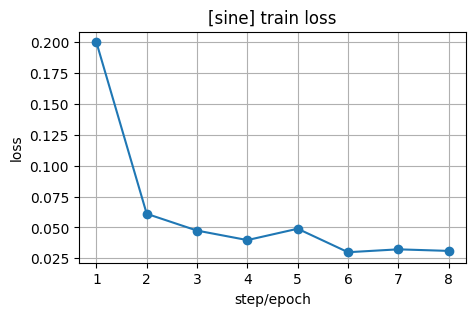

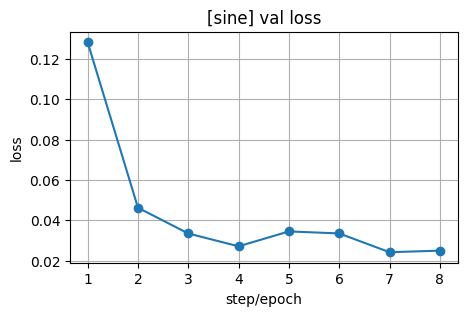

To be, or not to be, that is the question:
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of 
[rope] step 50: train=0.049 val=0.029
[rope] step 100: train=0.032 val=0.029
[rope] step 150: train=0.028 val=0.024
[rope] step 200: train=0.031 val=0.021
[rope] step 250: train=0.029 val=0.026
[rope] step 300: train=0.028 val=0.023
[rope] step 350: train=0.022 val=0.021
[rope] step 400: train=0.028 val=0.023


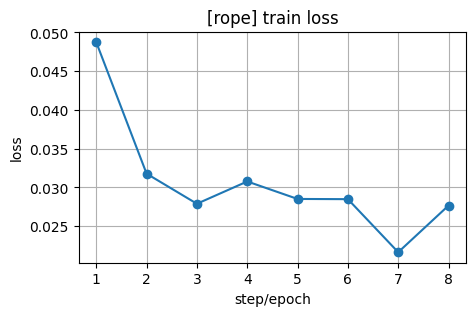

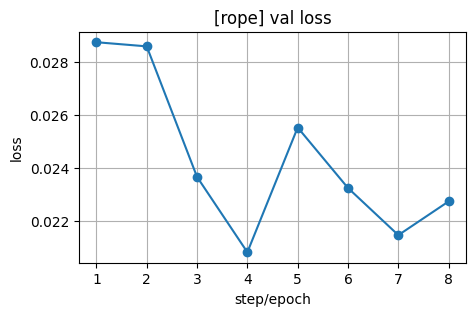

To be, or not to be, that is the question:
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of 


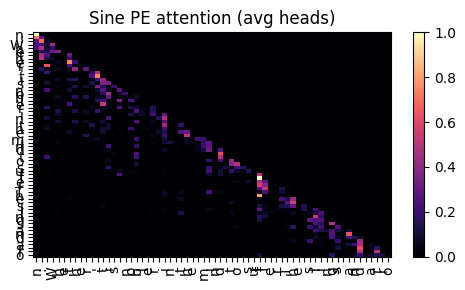

In [7]:
# ===== Запуск =====
model_sine, stoi, itos, tr_s, val_s = train_char_lm("sine", steps=400)
plot_curve(tr_s, "[sine] train loss"); plot_curve(val_s, "[sine] val loss")
print(sample(model_sine, stoi, itos, "To ", 160, temperature=1.0)[:300])

model_rope, _, _, tr_r, val_r = train_char_lm("rope", steps=400)
plot_curve(tr_r, "[rope] train loss"); plot_curve(val_r, "[rope] val loss")
print(sample(model_rope, stoi, itos, "To ", 160, temperature=1.0)[:300])

# Визуализация attention на коротком батче
x,_ = get_char_batches(tiny_char_data()[0], ctx=64, bs=1)
x = x.to(DEVICE)
with torch.no_grad():
    _, attns = model_sine(x)
att = attns[-1][0].mean(0).cpu().numpy()  # последний блок, среднее по головам
tok_seq = [list(stoi.keys())[list(stoi.values()).index(int(i))] for i in x[0].cpu().tolist()]
show_attention_heatmap(att, x_ticks=tok_seq, y_ticks=tok_seq, title="Sine PE attention (avg heads)")


In [8]:
# ===== Sanity-тесты (SDPA & RoPE) =====
def _no_nan(x):
    if torch.is_tensor(x): return torch.isfinite(x).all().item()
    return np.isfinite(x).all()

def check_sdpa(ScaledDotProductAttention):
    print("[SDPA] sanity")
    B,h,T,d = 2,3,6,8
    Q = torch.randn(B,h,T,d); K = torch.randn(B,h,T,d); V = torch.randn(B,h,T,d)
    mask = causal_mask(T, Q.device)
    sdpa = ScaledDotProductAttention(0.0)
    out, P = sdpa(Q,K,V,attn_mask=mask)
    assert out.shape == (B,h,T,d) and P.shape==(B,h,T,T)
    assert _no_nan(out) and _no_nan(P)
    s = P.sum(-1)
    allowed_rows = mask.squeeze(0).squeeze(0).any(-1)
    for bi in range(B):
        for hi in range(h):
            vals = s[bi,hi,allowed_rows]
            assert torch.allclose(vals, torch.ones_like(vals), atol=1e-4)
    iu = torch.triu_indices(T,T,1)
    assert (P[0,0].detach().numpy()[iu[0], iu[1]] < 1e-5).all()
    print("  PASS")

def check_rope(rope_rotate):
    print("[RoPE] sanity")
    B,h,T,d = 1,2,5,8
    x = torch.randn(B,h,T,d)
    cos, sin = rope_cache(T, d, x.device)
    xr = rope_rotate(x, cos, sin)
    assert xr.shape == x.shape and _no_nan(xr)
    n1 = torch.linalg.vector_norm(x, dim=-1)
    n2 = torch.linalg.vector_norm(xr, dim=-1)
    assert torch.allclose(n1, n2, atol=1e-5)
    q, k = torch.randn(B,h,T,d), torch.randn(B,h,T,d)
    qr, kr = rope_rotate(q, cos, sin), rope_rotate(k, cos, sin)
    d1 = (q*k).sum(-1); d2 = (qr*kr).sum(-1)
    assert torch.allclose(d1, d2, atol=1e-5)
    print("  PASS")

check_sdpa(ScaledDotProductAttention)
check_rope(rope_rotate)


[SDPA] sanity
  PASS
[RoPE] sanity
  PASS


In [9]:
@torch.no_grad()
def estimate_loss_ppl(model, ids, ctx=128, bs=32, eval_iters=50):
    model.eval()
    V = model.head.out_features
    losses = []
    for _ in range(eval_iters):
        x, y = get_char_batches(ids, ctx=ctx, bs=bs)
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits, _ = model(x)
        loss = F.cross_entropy(logits.view(-1, V), y.view(-1))
        losses.append(loss.item())
    mean_loss = sum(losses) / len(losses)
    ppl = math.exp(mean_loss)
    return mean_loss, ppl


In [10]:
train_ids, val_ids, stoi, itos = tiny_char_data()

loss_s_tr, ppl_s_tr = estimate_loss_ppl(model_sine, train_ids, ctx=128, bs=32, eval_iters=50)
loss_s_va, ppl_s_va = estimate_loss_ppl(model_sine, val_ids,   ctx=128, bs=32, eval_iters=50)

loss_r_tr, ppl_r_tr = estimate_loss_ppl(model_rope, train_ids, ctx=128, bs=32, eval_iters=50)
loss_r_va, ppl_r_va = estimate_loss_ppl(model_rope, val_ids,   ctx=128, bs=32, eval_iters=50)

print(f"SINE: train loss={loss_s_tr:.3f}, ppl={ppl_s_tr:.2f} | val loss={loss_s_va:.3f}, ppl={ppl_s_va:.2f}")
print(f"ROPE: train loss={loss_r_tr:.3f}, ppl={ppl_r_tr:.2f} | val loss={loss_r_va:.3f}, ppl={ppl_r_va:.2f}")


SINE: train loss=0.023, ppl=1.02 | val loss=0.023, ppl=1.02
ROPE: train loss=0.023, ppl=1.02 | val loss=0.022, ppl=1.02


In [11]:
ppl_tr_s  = [math.exp(x) for x in tr_s]
ppl_val_s = [math.exp(x) for x in val_s]
ppl_tr_r  = [math.exp(x) for x in tr_r]
ppl_val_r = [math.exp(x) for x in val_r]

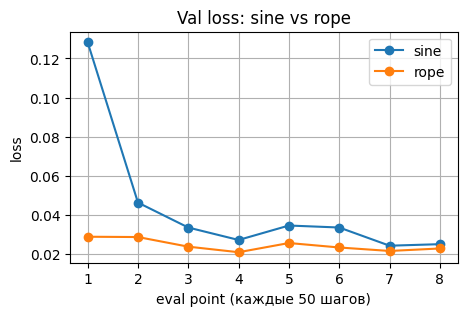

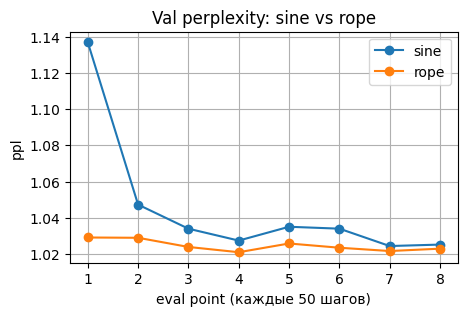

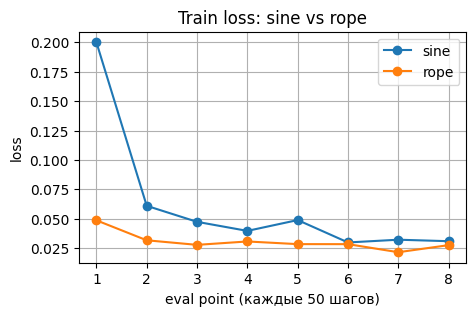

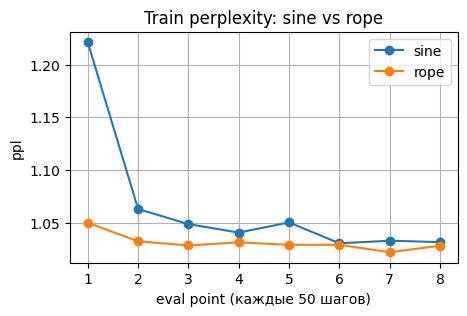

In [12]:
def sine_vs_rope(a, b, title, labels=("sine", "rope"), ylabel="value"):
    xs = np.arange(1, len(a)+1)
    plt.figure()
    plt.plot(xs, a, marker="o", label=labels[0])
    plt.plot(xs, b, marker="o", label=labels[1])
    plt.grid(True); plt.title(title); plt.xlabel("eval point (каждые 50 шагов)")
    plt.ylabel(ylabel); plt.legend(); plt.show()

sine_vs_rope(val_s, val_r, "Val loss: sine vs rope", ylabel="loss")
sine_vs_rope(ppl_val_s, ppl_val_r, "Val perplexity: sine vs rope", ylabel="ppl")

sine_vs_rope(tr_s, tr_r, "Train loss: sine vs rope", ylabel="loss")
sine_vs_rope(ppl_tr_s, ppl_tr_r, "Train perplexity: sine vs rope", ylabel="ppl")
